# Эффект AVO (Amplitude Versus Offset)

Эффект AVO (изменение амплитуды отражённой волны в зависимости от удаления) — это важнейший инструмент сейсморазведки, позволяющий получать информацию о флюидах и литологии в пластах. При анализе сейсмических данных из разных удалений (offsets) можно наблюдать характерные изменения амплитуды отражения, которые связаны с физическими свойствами горных пород и насыщающих их флюидов.

### Уравнение Цёпритца
Полное уравнение Цёпритца описывает зависимость коэффициента отражения на границе двух сред от Vp, Vs, rho и углов падения и преломления:

$$R(\theta) = \frac{1}{D} \left[ F(b \cos\theta_1/v_{P1} - c \cos\theta_2/v_{P2}) - p^2 G(a + d \cos\theta_2/v_{P2} \cos\phi_1/v_{S1}) \right]$$

где:
- $\theta_1, \theta_2$ — углы падения и преломления P-волн
- $\phi_1, \phi_2$ — углы падения и преломления S-волн
- $v_{P1}, v_{P2}, v_{S1}, v_{S2}$ — скорости P и S волн в двух средах
- $\rho_1, \rho_2$ — плотности двух сред
- $p = \sin\theta_1 / v_{P1}$ — параметр луча

### Приближение Шуэ (Shuey)

Для малых углов ($\theta < 20^\circ$) применяется двухчленное приближение:

$$
R(\theta) \approx R(0) + G \sin^2\theta
$$

Параметры:

$$
\begin{align*}
R(0) &= \frac{1}{2} \left( \frac{\Delta v_P}{v_P} + \frac{\Delta \rho}{\rho} \right) 
&& \text{— отражение при нормальном падении} \\[1em]
G &= R(0) - 2 \frac{v_S^2}{v_P^2} \left( \frac{\Delta \rho}{\rho} + 2 \frac{\Delta v_S}{v_S} \right) 
&& \text{— градиент AVO}
\end{align*}
$$

Это приближение очень популярно в практическом AVO-анализе благодаря:
- хорошей точности при малых углах,
- простой физической интерпретации градиента $G$.

### Классификация AVO по Ратерфорду и Хитчкоку
Существует несколько классов AVO-аномалий, характеризующихся различным поведением амплитуды при увеличении угла:

- **Класс 1**: Амплитуда увеличивается с углом (обычно газ в песчанике под глиной)
- **Класс 2**: Амплитуда при нулевом угле близка к нулю, но увеличивается с углом
- **Класс 3**: Амплитуда отрицательна при нулевом угле и становится более отрицательной с увеличением угла
- **Класс 4**: Амплитуда отрицательна при нулевом угле, но уменьшается по модулю с увеличением угла

В этом ноутбуке мы:
1. Создадим двухслойную 2D модель для 3-го класса AVO-аномалий
2. Получим сейсмограмму ОГТ из серии упругих симуляций для разных пар источник-приемник, так чтобы было покрытие точки отражения разными углами
3. Снимем амплитуды с гиперболы отражения и вынесем на график 
4. Сравним с теоретическими решениями по Цёпритцу и по Шуэ

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from numba import jit
from tqdm.notebook import tqdm

import segyio
from scipy.signal import filtfilt, butter

### 1. Создаем модель и съёмку

In [2]:
nx = 201          
nz = 151        
dx = 5.0        
dz = 5.0          
x = np.arange(nx) * dx
z = np.arange(nz) * dz

# Верхний слой — глина (до глубины thick1)
# Второй слой — газовый песок (от thick1 до конца модели)

vp1 = 2500.0  # m/s
vs1 = 1000.0  # m/s
rho1 = 2200    # kg/m³

vp2 = 2000.0  # m/s
vs2 = 1200.0  # m/s
rho2 = 2000   # kg/m³

thick1 = 500.0   # толщина верхнего слоя 

# Инициализация моделей
vp = np.ones((nz, nx)) * vp1  
vs = np.ones((nz, nx)) * vs1  
rho = np.ones((nz, nx)) * rho1    
z1 = int(thick1 / dz)            
vp[z1:, :] = vp2
vs[z1:, :] = vs2
rho[z1:, :] = rho2

In [3]:
# ========== Создание CMP съёмки ==========
# Координата средней точки
midpoint_x = 500.0

# Массив полу-оффсетов (расстояний от CMP до источника/приемника)

max_half_offset = min(midpoint_x, nx*dx - midpoint_x)
half_offset_step = 25
half_offsets = np.arange(0, max_half_offset + half_offset_step, half_offset_step)
n_half_offsets = len(half_offsets)

# Координаты пар источник/приемника
sources_x = []
receivers_x = []

for half_offset in half_offsets:
    # Источник слева от CMP, приемник справа
    src_x = midpoint_x - half_offset
    rec_x = midpoint_x + half_offset

    # Проверка попадания в пределы модели
    if src_x >= 0 and rec_x <= nx*dx:
        sources_x.append(src_x)
        receivers_x.append(rec_x)

sources_x = np.array(sources_x)
receivers_x = np.array(receivers_x)

# Координата целевой точки отражения
reflection_point_x = midpoint_x
reflection_point_z = thick1

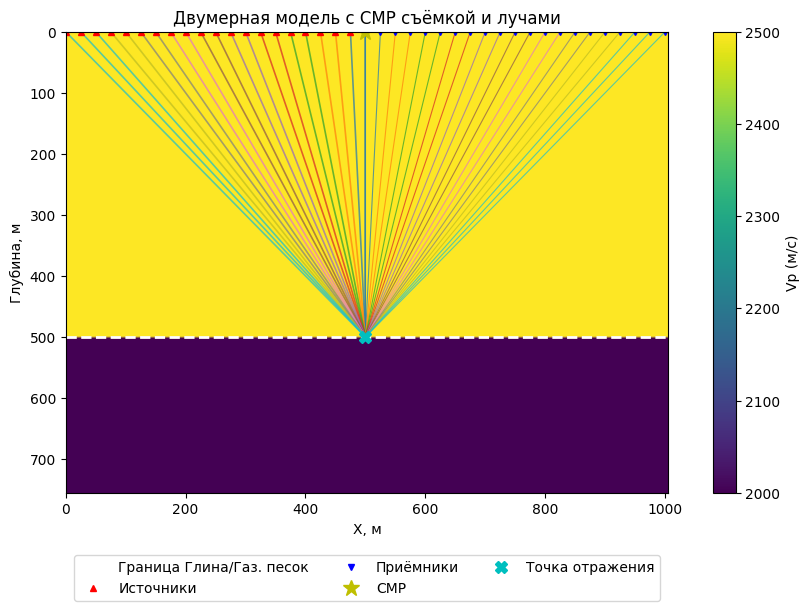

In [4]:
# ======= Визуализация: Модель + Лучи =======
fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)

colors = plt.cm.tab10(np.linspace(0, 1, len(sources_x)))

# Отображаем Vp модель
im = ax.imshow(vp, extent=[0, nx*dx, nz*dz, 0], aspect='auto', cmap='viridis')

# Рисуем границы слоёв
ax.axhline(y=thick1, color='white', linestyle='--', linewidth=2, label='Граница Глина/Газ. песок')

alpha_value=0.7

# Рисуем лучи для каждой пары источник-приёмник
for i in range(len(sources_x)):
    src_x = sources_x[i]
    rec_x = receivers_x[i]   
    pair_color = colors[i]

    # Луч от источника до точки отражения
    ax.plot([src_x, reflection_point_x], [0, reflection_point_z], 
            color=pair_color, linewidth=1.2, alpha=alpha_value) 

    # Луч от точки отражения до приёмника
    ax.plot([reflection_point_x, rec_x], [reflection_point_z, 0], color=pair_color, linewidth=0.8, alpha=0.7)

# Добавляем источники и приёмники для максимального удаления
if len(sources_x) > 0:
    ax.plot(sources_x, np.zeros_like(sources_x), 'r^', markersize=5, label='Источники')
    ax.plot(receivers_x, np.zeros_like(receivers_x), 'bv', markersize=5, label='Приёмники')
    ax.plot(midpoint_x, 0, 'y*', markersize=12, label='CMP')
    ax.plot(reflection_point_x, reflection_point_z, 'cX', markersize=8, label='Точка отражения')

ax.set_xlabel('X, м')
ax.set_ylabel('Глубина, м')
ax.set_title('Двумерная модель с CMP съёмкой и лучами')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=3)
fig.colorbar(im, ax=ax, label='Vp (м/с)')


### 2. Функции для упругого моделирования

In [5]:
@jit(nopython=True, cache=True)
def _fd_step_4th_order_staggered(
    vx, vz, sxx, szz, sxz,
    lam, mu, bux, buz, muxz, absorb,
    dx, dz, dt, nx, nz,
    isrc, jsrc, source_val
):
    # Коэффициенты для Staggered Grid 4th order
    c1 = 9.0 / 8.0
    c2 = -1.0 / 24.0

    # 1. ОБНОВЛЕНИЕ СКОРОСТЕЙ (используем напряжения)
    for i in range(2, nx - 2):
        for j in range(2, nz - 2):
            # vx(i+1/2, j)
            # Производные по x от sxx [i-1, i, i+1, i+2] -> несимметрично для staggered
            # Но стандартная схема: dsxx/dx в точке i+1/2 использует sxx в i, i+1, i-1, i+2
            dsxx_dx = (c1 * (sxx[i+1, j] - sxx[i, j]) + 
                       c2 * (sxx[i+2, j] - sxx[i-1, j])) / dx
            # dsxz/dz в точке j использует sxz в j-1/2, j+1/2...
            dsxz_dz = (c1 * (sxz[i, j] - sxz[i, j-1]) + 
                       c2 * (sxz[i, j+1] - sxz[i, j-2])) / dz
            
            vx[i, j] = (vx[i, j] + dt * bux[i, j] * (dsxx_dx + dsxz_dz)) * absorb[i, j]

    for i in range(2, nx - 2):
        for j in range(2, nz - 2):
            # vz(i, j+1/2)
            dsxz_dx = (c1 * (sxz[i, j] - sxz[i-1, j]) + 
                       c2 * (sxz[i+1, j] - sxz[i-2, j])) / dx
            dszz_dz = (c1 * (szz[i, j+1] - szz[i, j]) + 
                       c2 * (szz[i, j+2] - szz[i, j-1])) / dz
            
            vz[i, j] = (vz[i, j] + dt * buz[i, j] * (dsxz_dx + dszz_dz)) * absorb[i, j]

    # 2. ОБНОВЛЕНИЕ НАПРЯЖЕНИЙ (используем скорости)
    for i in range(2, nx - 2):
        for j in range(2, nz - 2):
            # sxx, szz в (i, j)
            dvx_dx = (c1 * (vx[i, j] - vx[i-1, j]) + 
                      c2 * (vx[i+1, j] - vx[i-2, j])) / dx
            dvz_dz = (c1 * (vz[i, j] - vz[i, j-1]) + 
                      c2 * (vz[i, j+1] - vz[i, j-2])) / dz
            
            l2m = lam[i, j] + 2.0 * mu[i, j]
            sxx[i, j] = (sxx[i, j] + dt * (l2m * dvx_dx + lam[i, j] * dvz_dz)) * absorb[i, j]
            szz[i, j] = (szz[i, j] + dt * (lam[i, j] * dvx_dx + l2m * dvz_dz)) * absorb[i, j]

    for i in range(2, nx - 2):
        for j in range(2, nz - 2):
            # sxz в (i+1/2, j+1/2)
            dvx_dz = (c1 * (vx[i, j+1] - vx[i, j]) + 
                      c2 * (vx[i, j+2] - vx[i, j-1])) / dz
            dvz_dx = (c1 * (vz[i+1, j] - vz[i, j]) + 
                      c2 * (vz[i+2, j] - vz[i-1, j])) / dx
            
            sxz[i, j] = (sxz[i, j] + dt * muxz[i, j] * (dvx_dz + dvz_dx)) * absorb[i, j]

    # 3. ИСТОЧНИК
    sxx[isrc, jsrc] += source_val
    szz[isrc, jsrc] += source_val

def fd2d_elastic_forward(src, vp, vs, rho, nt, dt, dx, dz, xsrc, zsrc, n_absorb=50):
    """
    Главная функция запуска. Принимает параметры в (nz, nx)
    """
    # Подготовка параметров (транспонируем в [nx, nz])
    vp = vp.T
    vs = vs.T
    rho = rho.T
    nx_in, nz_in = vp.shape

    # Паддинг для поглощающих границ
    pad = ((n_absorb, n_absorb), (n_absorb, n_absorb))
    vp_p = np.pad(vp, pad, mode='edge')
    vs_p = np.pad(vs, pad, mode='edge')
    rho_p = np.pad(rho, pad, mode='edge')
    nx, nz = vp_p.shape

    # Расчет коэффициентов Ламе
    mu = rho_p * vs_p**2
    lam = rho_p * vp_p**2 - 2.0 * mu
    
    # Усреднение материальных параметров для разнесенной сетки
    # bux (1/rho усредненное по x), buz (1/rho усредненное по z)
    b = 1.0 / rho_p
    bux = np.zeros_like(b)
    buz = np.zeros_like(b)
    muxz = np.zeros_like(mu)

    for i in range(1, nx-1):
        for j in range(1, nz-1):
            bux[i, j] = 0.5 * (b[i, j] + b[i+1, j])
            buz[i, j] = 0.5 * (b[i, j] + b[i, j+1])
            # Гармоническое усреднение mu для sxz (в углах ячеек)
            muxz[i, j] = 4.0 / (1/mu[i, j] + 1/mu[i+1, j] + 1/mu[i, j+1] + 1/mu[i+1, j+1])

    # Поглощающий слой (Exponential Dampening)
    absorb = np.ones((nx, nz), dtype='float32')
    v = 0.01
    for i in range(n_absorb):
        damp = np.exp(-(v * (n_absorb - i))**2)
        absorb[i, :] *= damp
        absorb[nx-i-1, :] *= damp
        absorb[:, i] *= damp
        absorb[:, nz-i-1] *= damp

    # Инициализация полей
    vx = np.zeros((nx, nz), dtype='float32')
    vz = np.zeros((nx, nz), dtype='float32')
    sxx = np.zeros((nx, nz), dtype='float32')
    szz = np.zeros((nx, nz), dtype='float32')
    sxz = np.zeros((nx, nz), dtype='float32')

    # Выходные данные
    isrc = int(xsrc / dx) + n_absorb
    jsrc = int(zsrc / dz) + n_absorb
    vx_out = np.zeros((nt, nz_in, nx_in), dtype='float32')
    vz_out = np.zeros((nt, nz_in, nx_in), dtype='float32')
    p_out = np.zeros((nt, nz_in, nx_in), dtype='float32')

    for it in tqdm(range(nt)):
        source_val = src[it]
        _fd_step_4th_order_staggered(
            vx, vz, sxx, szz, sxz,
            lam, mu, bux, buz, muxz, absorb,
            dx, dz, dt, nx, nz,
            isrc, jsrc, source_val
        )
        # Срезаем паддинг и возвращаем в (nz, nx)
        core_vx = vx[n_absorb:-n_absorb, n_absorb:-n_absorb]
        core_vz = vz[n_absorb:-n_absorb, n_absorb:-n_absorb]
        core_sxx = sxx[n_absorb:-n_absorb, n_absorb:-n_absorb]
        core_szz = szz[n_absorb:-n_absorb, n_absorb:-n_absorb]

        vx_out[it] = core_vx.T
        vz_out[it] = core_vz.T
        # Давление ~ -(sxx + szz) / 2 (изотропное приближение)
        p_out[it] = (-(core_sxx + core_szz) * 0.5).T

    return vx_out, vz_out, p_out

def ricker_wavelet(f0, dt, nt):    
    t = np.arange(nt) * dt - 0.5 / f0  # Центрируем волновой пакет
    wavelet = (1.0 - 2.0 * (np.pi * f0 * t) ** 2) * np.exp(-(np.pi * f0 * t) ** 2)
    return wavelet.astype(np.float32)

In [6]:
# ================== КОНСТАНТЫ СИМУЛЯЦИИ ==================
# Параметры временного шага и продолжительности
DT_MS = 0.6          # Временной шаг в миллисекундах
T_MAX_S = 0.8      # Максимальное время симуляции в секундах
NT = int(T_MAX_S / (DT_MS * 0.001))  # Количество временных шагов

# Параметры источника (Ricker wavelet)
F0 = 25.0            # Центральная частота в Гц

In [7]:
# Создаем волновой пакет
source_wavelet = ricker_wavelet(F0, DT_MS*0.001, NT) * 10e6  

# Вычисляем offsets для каждой пары
offsets = receivers_x - sources_x    

print(f"Запуск симуляции для {len(sources_x)} пар источник-приемник...")

# Списки для накопления трасс
vz_traces = []
p_traces = []
trace_info = []  # Будем хранить информацию о каждой трассе

# Симулируем каждую пару источник-приемник
for i, (src_x, rec_x) in enumerate(zip(sources_x, receivers_x)):
    print(f"Симуляция для пары {i+1}/{len(sources_x)} (источник: {src_x:.1f} м, приемник: {rec_x:.1f} м, offset: {rec_x - src_x:.1f} м)")
    
    # Выполняем упругую симуляцию
    # Источник расположен на поверхности (z=0)
    vx_out, vz_out, p_out = fd2d_elastic_forward(
        src=source_wavelet,
        vp=vp,
        vs=vs,
        rho=rho,
        nt=NT,
        dt=DT_MS*0.001,
        dx=dx,
        dz=dz,
        xsrc=src_x,
        zsrc=0.0,
        n_absorb=50
    )
    
    # Извлекаем данные для конкретного приемника на поверхности (z=0)
    rec_idx = int(np.round(rec_x / dx))
    surface_idx = 0  # Индекс поверхности (z=0)
    
    # Извлекаем вертикальную компоненту скорости для приемника на поверхности
    vz_trace = vz_out[:, surface_idx, rec_idx]    
    
    # Сохраняем трассы и информацию о них
    vz_traces.append(vz_trace)    
    trace_info.append({
        'src_x': src_x,
        'rec_x': rec_x,
        'offset': rec_x - src_x
    })

# Преобразуем списки в массивы
vz_data = np.array(vz_traces).T  # Форма: (nt, n_traces)

# Сортируем трассы по offset (удалению)
offsets_array = np.array([info['offset'] for info in trace_info])
print(offsets_array)
sort_indices = np.argsort(offsets_array)

# Сортируем данные и информацию
seismogram = vz_data[:, sort_indices]

Запуск симуляции для 21 пар источник-приемник...
Симуляция для пары 1/21 (источник: 500.0 м, приемник: 500.0 м, offset: 0.0 м)


  0%|          | 0/1333 [00:00<?, ?it/s]

Симуляция для пары 2/21 (источник: 475.0 м, приемник: 525.0 м, offset: 50.0 м)


  0%|          | 0/1333 [00:00<?, ?it/s]

Симуляция для пары 3/21 (источник: 450.0 м, приемник: 550.0 м, offset: 100.0 м)


...

Симуляция для пары 20/21 (источник: 25.0 м, приемник: 975.0 м, offset: 950.0 м)


  0%|          | 0/1333 [00:00<?, ?it/s]

Симуляция для пары 21/21 (источник: 0.0 м, приемник: 1000.0 м, offset: 1000.0 м)


  0%|          | 0/1333 [00:00<?, ?it/s]

[   0.   50.  100.  150.  200.  250.  300.  350.  400.  450.  500.  550.
  600.  650.  700.  750.  800.  850.  900.  950. 1000.]


### 3. Функции для AVO анализа

In [10]:
def calculate_hyperbola_times(t0, velocity, offsets):
    """
    Вычисляет времена гиперболы отражения для CMP-сбора.
    
    Параметры:
    t0 : float
        Время при нулевом удалении (секунды)
    velocity : float
        Скорость над отражающей границей (м/с)
    half_offsets : array_like
        Массив оффсетов от cmp до приемника (источника)
    
    Возвращает:
    t_hyperbola : ndarray
        Времена прихода отражённой волны для каждого оффсета
    """
    # Используем полные оффсеты без деления на 2
    t_hyperbola = np.sqrt(t0**2 + (offsets / velocity)**2)
    return t_hyperbola

def extract_amplitudes_around_hyperbola(data, times_s, t_hyperbola, window_ms):
    """
    Извлекает амплитуды по максимумам в окне вокруг гиперболы.
    
    Параметры:
    data : массив данных (nt, n_traces)
    times_s : временная ось в секундах
    t_hyperbola : времена гиперболы для каждой трассы
    window_ms : ширина окна в миллисекундах
    
    Возвращает:
    amplitudes : массив амплитуд для каждой трассы
    """
    window_s = window_ms / 1000.0
    amplitudes = []
    
    for i, t_hyp in enumerate(t_hyperbola):
        # Находим индексы временных отсчетов в окне вокруг гиперболы
        window_start = t_hyp - window_s / 2.0
        window_end = t_hyp + window_s / 2.0
        
        # Находим индексы в массиве times_s
        idx_start = np.searchsorted(times_s, window_start)
        idx_end = np.searchsorted(times_s, window_end)
        
        # Обеспечиваем корректные границы
        idx_start = max(0, idx_start)
        idx_end = min(len(times_s), idx_end)
        
        if idx_end > idx_start:
            # Извлекаем данные в окне и находим максимум
            window_data = data[idx_start:idx_end, i]
            amplitudes.append(window_data[np.argmax(np.abs(window_data))])
        else:
            # Если окно пустое, используем 0
            amplitudes.append(0.0)
    
    return np.array(amplitudes)

def offset_to_angle(full_offset, t0, velocity):
    """
    Пересчитывает полный оффсет в угол падения.
    
    Параметры:
    full_offset : полный оффсет (м) - расстояние источник-приемник
    t0 : время при нулевом удалении (с)
    velocity : скорость (м/с)
    
    Возвращает:
    angle_deg : угол падения в градусах
    """
    # Преобразуем полный оффсет в полуоффсет
    half_offset = full_offset / 2.0
    # Глубина отражающей границы
    depth = velocity * t0 / 2.0
    # Угол падения (в радианах) - используем полуоффсет
    angle_rad = np.arctan(half_offset / depth)
    # Преобразуем в градусы
    angle_deg = np.degrees(angle_rad)
    return angle_deg

### 4. Функции для уравнения Цёпритца и аппроксимации Шуэ

In [12]:
def zoeppritz_pp(vp1, vs1, rho1, vp2, vs2, rho2, theta1_deg):
    """Calculate PP reflection coefficient using the full Zoeppritz equations."""
    # Convert to radians
    theta1 = np.radians(theta1_deg)
    # Ray parameter
    p = np.sin(theta1) / vp1
    # Snell's law (with complex arithmetic to handle post-critical angles)
    theta2 = np.arcsin(p * vp2 + 0j)
    phi1 = np.arcsin(p * vs1 + 0j)
    phi2 = np.arcsin(p * vs2 + 0j)

    # Helper variables
    a = rho2 * (1.0 - 2.0 * np.sin(phi2)**2) - rho1 * (1.0 - 2.0 * np.sin(phi1)**2)
    b = rho2 * (1.0 - 2.0 * np.sin(phi2)**2) + 2.0 * rho1 * np.sin(phi1)**2
    c = rho1 * (1.0 - 2.0 * np.sin(phi1)**2) + 2.0 * rho2 * np.sin(phi2)**2
    d = 2.0 * (rho2 * vs2**2 - rho1 * vs1**2)

    E = (b * np.cos(theta1) / vp1) + (c * np.cos(theta2) / vp2)
    F = (b * np.cos(phi1) / vs1) + (c * np.cos(phi2) / vs2)
    G = a - d * (np.cos(theta1) / vp1) * (np.cos(phi2) / vs2)
    H = a - d * (np.cos(theta2) / vp2) * (np.cos(phi1) / vs1)
    D = E * F + G * H * p**2

    # PP reflection coefficient
    numerator = (F * (b * np.cos(theta1) / vp1 - c * np.cos(theta2) / vp2) -
                 p**2 * G * (a + d * (np.cos(theta2) / vp2) * (np.cos(phi1) / vs1)))
    rpp = numerator / D

    return rpp.real

In [13]:
def shuey_approximation(vp1, vs1, rho1, vp2, vs2, rho2, theta1_deg):
    """
    Calculate PP reflection coefficient using Shuey's approximation (2-term).
    
    Parameters:
    vp1, vs1, rho1 : float
        P-wave velocity, S-wave velocity, and density of the upper medium
    vp2, vs2, rho2 : float
        P-wave velocity, S-wave velocity, and density of the lower medium
    theta1_deg : float or array-like
        Incidence angle(s) in degrees
    
    Returns:
    rpp : float or ndarray
        PP reflection coefficient(s) using Shuey's approximation
    """
    # Convert to radians
    theta1 = np.radians(theta1_deg)
    
    # Calculate average properties
    vp_avg = (vp1 + vp2) / 2.0
    vs_avg = (vs1 + vs2) / 2.0
    rho_avg = (rho1 + rho2) / 2.0
    
    # Calculate differences
    dvp = vp2 - vp1
    dvs = vs2 - vs1
    drho = rho2 - rho1
    
    # Calculate R(0) - reflection coefficient at normal incidence
    R0 = 0.5 * (dvp / vp_avg + drho / rho_avg)
    
    # Calculate AVO gradient G
    G = R0 - 2.0 * (vs_avg / vp_avg)**2 * (drho / rho_avg + 2.0 * dvs / vs_avg)
    
    # Shuey's 2-term approximation
    rpp = R0 + G * np.sin(theta1)**2
    
    return rpp

#### Предобработка сейсмограммы Vz 

In [15]:
# Компенсация геометрического расхождения по формуле A_corrected[offset, time] = A_synthetic[offset, time] × √(offset² + (v·t/2)²)
times_s = np.arange(0, NT * DT_MS, DT_MS) / 1000.0  # Временная ось в секундах

# Создаем массив для коэффициентов компенсации
# Форма: (nt, n_traces) - совпадает с формой seismogram
compensation_factors = np.zeros_like(seismogram)

# Вычисляем компенсационные коэффициенты для каждого временного отсчета и каждого оффсета
for i, t in enumerate(times_s):
    for j, offset in enumerate(offsets[sort_indices]):  # Используем отсортированные оффсеты
        compensation_factors[i, j] = np.sqrt(offset**2 + (vp1 * t / 2.0)**2)

# Применяем компенсацию
processed_seismogram = seismogram * compensation_factors

# Bandpass Filter 12-40 Hz
nyquist = 1000* 0.5 / DT_MS
low = 12 / nyquist
high = 40 / nyquist
b, a = butter(2, [low, high], btype='band')

# Фильтруем каждую трассу
for i in range(seismogram.shape[1]):
    processed_seismogram[:, i] = filtfilt(b, a, processed_seismogram[:, i])


#### Снятие амплитуд по максимуму в окне вокруг гиперболы

In [16]:
# Вычисляем времена гиперболы (используя полные оффсеты)
T0_S = 0.415
REFL_VEL = vp1
WINDOW_MS = 100.0

print(f"Вычисление гиперболы: t0={T0_S:.3f} с, скорость={REFL_VEL:.0f} м/с")
t_hyperbola = calculate_hyperbola_times(T0_S, REFL_VEL, offsets)

# Извлекаем амплитуды
print(f"Извлечение амплитуд в окне {WINDOW_MS:.0f} мс вокруг гиперболы...")
amplitudes = extract_amplitudes_around_hyperbola(
    processed_seismogram, times_s, t_hyperbola, WINDOW_MS
)



print("Вычисление теоретических коэффициентов отражения для сравнения")
# Пересчитываем полные оффсеты в углы
angles = np.array([offset_to_angle(offset, T0_S, REFL_VEL) for offset in offsets])
avo_zoeppritz = np.array([zoeppritz_pp(vp1, vs1, rho1, vp2, vs2, rho2, theta) 
                          for theta in angles])
avo_shuey = np.array([shuey_approximation(vp1, vs1, rho1, vp2, vs2, rho2, theta) 
                       for theta in angles])

Вычисление гиперболы: t0=0.415 с, скорость=2500 м/с
Извлечение амплитуд в окне 100 мс вокруг гиперболы...
Вычисление теоретических коэффициентов отражения для сравнения


#### Визуализация результатов

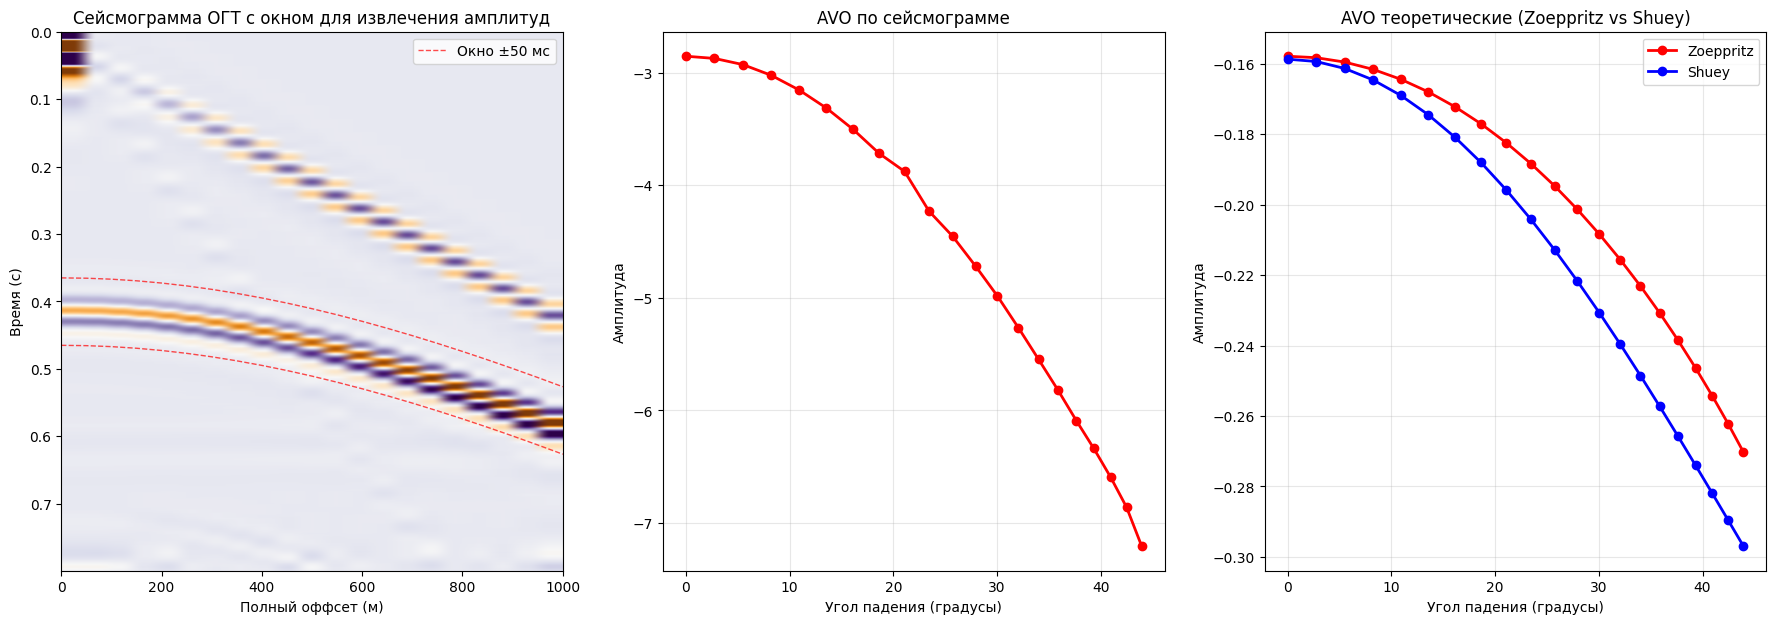

In [17]:
fig, ax = plt.subplots(1, 3, figsize=(22, 7))

window_s = WINDOW_MS/1000.0

vmin, vmax = np.percentile(processed_seismogram, [0.3, 99.7])

# Наносим сейсмограмму
im = ax[0].imshow(processed_seismogram, 
               extent=[offsets.min(), offsets.max(), times_s.max(), times_s.min()],
               aspect='auto', 
               cmap='PuOr',
               vmin=vmin, vmax= vmax)

# Наносим границы окна
window_upper = t_hyperbola - window_s / 2.0
window_lower = t_hyperbola + window_s / 2.0
ax[0].plot(offsets, window_upper, 'r--', linewidth=1, alpha=0.7, label=f'Окно ±{WINDOW_MS/2:.0f} мс')
ax[0].plot(offsets, window_lower, 'r--', linewidth=1, alpha=0.7)

ax[0].set_xlabel('Полный оффсет (м)')
ax[0].set_ylabel('Время (с)')
ax[0].set_title('Сейсмограмма ОГТ с окном для извлечения амплитуд')
ax[0].legend()

# График Amplitude vs Angle
ax[1].plot(angles, amplitudes, 'ro-', linewidth=2, markersize=6)
ax[1].set_xlabel('Угол падения (градусы)')
ax[1].set_ylabel('Амплитуда')
ax[1].set_title('AVO по сейсмограмме')
ax[1].grid(True, alpha=0.3)

# График Amplitude vs Angle
ax[2].plot(angles, avo_zoeppritz, 'ro-', linewidth=2, markersize=6, label='Zoeppritz')
ax[2].plot(angles, avo_shuey, 'bo-', linewidth=2, markersize=6, label='Shuey')
ax[2].set_xlabel('Угол падения (градусы)')
ax[2].set_ylabel('Амплитуда')
ax[2].set_title('AVO теоретические (Zoeppritz vs Shuey)')
ax[2].grid(True, alpha=0.3)
ax[2].legend()



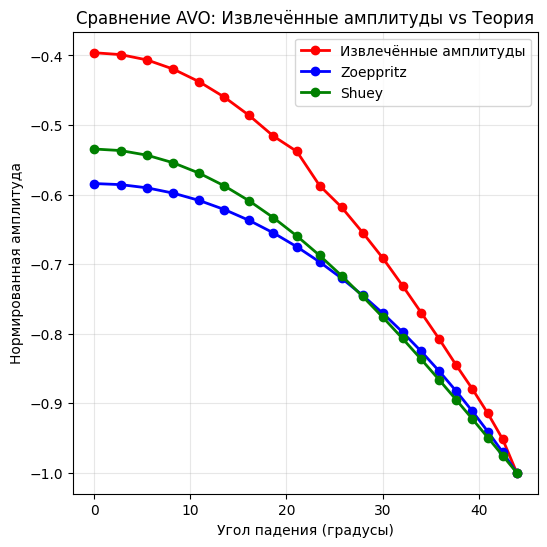

In [18]:
# отнормируем амплитуды для сравнения с теорией
amplitudes_norm = amplitudes / np.max(np.abs(amplitudes))
zoeppritz_norm = avo_zoeppritz / np.max(np.abs(avo_zoeppritz))
shuey_norm = avo_shuey / np.max(np.abs(avo_shuey))

plt.figure(figsize=(6, 6))
plt.plot(angles, amplitudes_norm, 'ro-', linewidth=2, markersize=6, label='Извлечённые амплитуды')
plt.plot(angles, zoeppritz_norm, 'bo-', linewidth=2, markersize=6, label='Zoeppritz')
plt.plot(angles, shuey_norm, 'go-', linewidth=2, markersize=6, label='Shuey')
plt.xlabel('Угол падения (градусы)')
plt.ylabel('Нормированная амплитуда')
plt.title('Сравнение AVO: Извлечённые амплитуды vs Теория')
plt.grid(True, alpha=0.3)
plt.legend()

Учитывая весьма упрощенную обработку сейсмограммы и неизбежные погрешности численной схемы, совпадение весьма неплохое. Главное, сам характер поведения кривой - отрицательный R, убывающий с углом - сохранился. 